In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [51]:
# -------------------------
# Base Generators (Single Channel)
# -------------------------

def generate_trend_channel(T):
    t = np.linspace(0, 1, T)
    a = np.random.uniform(1.0, 3.0)
    b = np.random.uniform(-1.0, 1.0)
    return a * t**2 + b * t + np.random.normal(0, 0.05, T)


def generate_sine_channel(T):
    t = np.linspace(0, 1, T)
    freq = np.random.uniform(2, 5)
    phase = np.random.uniform(0, 2*np.pi)
    return np.sin(2 * np.pi * freq * t + phase) + np.random.normal(0, 0.05, T)


def generate_ar_channel(T):
    X = np.zeros(T)
    phi = np.random.uniform(0.4, 0.7)
    noise = np.random.normal(0, 0.01, T)
    
    for t in range(1, T):
        X[t] = phi * X[t-1] + noise[t]
    
    return X


# -------------------------
# Anomaly Injection (per channel type)
# -------------------------

def inject_trend_anomaly_channel(x, start, length):
    for t in range(start, start + length):
        delta = x[t] - x[start]
        x[t] -= (1.25 * delta**2) + 0.5 * delta
    return x


def inject_sine_anomaly_channel(x, start, length):
    segment = x[start:start+length].copy()
    
    # small amplitude change
    segment *= np.random.uniform(0.9, 1.1)
    
    # slight drift
    drift = np.linspace(0, np.random.uniform(-0.2, 0.2), length)
    segment += drift
    
    # small noise
    segment += np.random.normal(0, 0.02, length)
    
    x[start:start+length] = segment
    return x


def inject_ar_anomaly_channel(x, start, length):
    noise = np.random.normal(0, 0.05, length)
    x[start:start+length] = noise
    return x


# -------------------------
# Main Dataset Generator
# -------------------------

def generate_dataset(
    T=200000,
    d=15,
    anomaly_length= None,
    n_anomalies=10,
    train_ratio=0.7,
    max_channels_per_anomaly=5,
    type = 'trend'
):
    
    X = np.zeros((T, d))
    y = np.zeros(T)
    
    # -------------------------
    # Channel setup
    # -------------------------
    
    d1 = d // 3
    d2 = d // 3
    d3 = d - d1 - d2
    
    channel_types = []
    
    if type == 'trend':
        for j in range(d):
            if j < d1:
                X[:, j] = generate_trend_channel(T)
                channel_types.append("trend")
            elif j < d1 + d2:
                X[:, j] = generate_trend_channel(T)
                channel_types.append("trend")
            else:
                X[:, j] = generate_trend_channel(T)
                channel_types.append("trend")
    elif type == 'sine':
        for j in range(d):
            if j < d1:
                X[:, j] = generate_sine_channel(T)
                channel_types.append("sine")
            elif j < d1 + d2:
                X[:, j] = generate_sine_channel(T)
                channel_types.append("sine")
            else:
                X[:, j] = generate_sine_channel(T)
                channel_types.append("sine")
    else:
        for j in range(d):
            if j < d1:
                X[:, j] = generate_ar_channel(T)
                channel_types.append("ar")
            elif j < d1 + d2:
                X[:, j] = generate_ar_channel(T)
                channel_types.append("ar")
            else:
                X[:, j] = generate_ar_channel(T)
                channel_types.append("ar")
    
    
    # -------------------------
    # Define clean training region
    # -------------------------
    
    train_end = int(T * train_ratio)
    
    # -------------------------
    # Inject multiple anomalies
    # -------------------------
    
    anomaly_starts = []
    
    for _ in range(n_anomalies):
        
        # Ensure anomalies occur AFTER training region
        anomaly_length= np.random.randint(1, 16)
        start = np.random.randint(train_end, T - anomaly_length)
        
        anomaly_starts.append(start)
        
        # Random subset of channels
        k = np.random.randint(1, max_channels_per_anomaly + 1)
        affected_channels = np.random.choice(d, size=k, replace=False)
        
        for j in affected_channels:
            if channel_types[j] == "trend":
                X[:, j] = inject_trend_anomaly_channel(X[:, j], start, anomaly_length)
            elif channel_types[j] == "sine":
                X[:, j] = inject_sine_anomaly_channel(X[:, j], start, anomaly_length)
            else:
                X[:, j] = inject_ar_anomaly_channel(X[:, j], start, anomaly_length)
        
        # Label anomaly window (union across all channels)
        y[start:start + anomaly_length] = 1
    
    return X, y, anomaly_starts

In [24]:
print(start)
min(start)

[171791, 169076, 145848, 188354, 194663, 193905, 161978, 154911, 196009, 163022]


145848

In [53]:
def plot_mts(X, y): #, regimes):
    T, d = X.shape
    t = np.arange(T)
    
    fig, axes = plt.subplots(d, 1, figsize=(20, 10), sharex=True)
    
    if d == 1:
        axes = [axes]
    
    for j in range(d):
        axes[j].plot(t, X[:, j])
        
        # Highlight anomalies
        anomaly_idx = np.where(y == 1)[0]
        axes[j].scatter(anomaly_idx, X[anomaly_idx, j], s=10)
        
        axes[j].set_ylabel(f"Channel {j}")
    
    
    axes[-1].set_xlabel("Time")
    plt.tight_layout()
    plt.show()

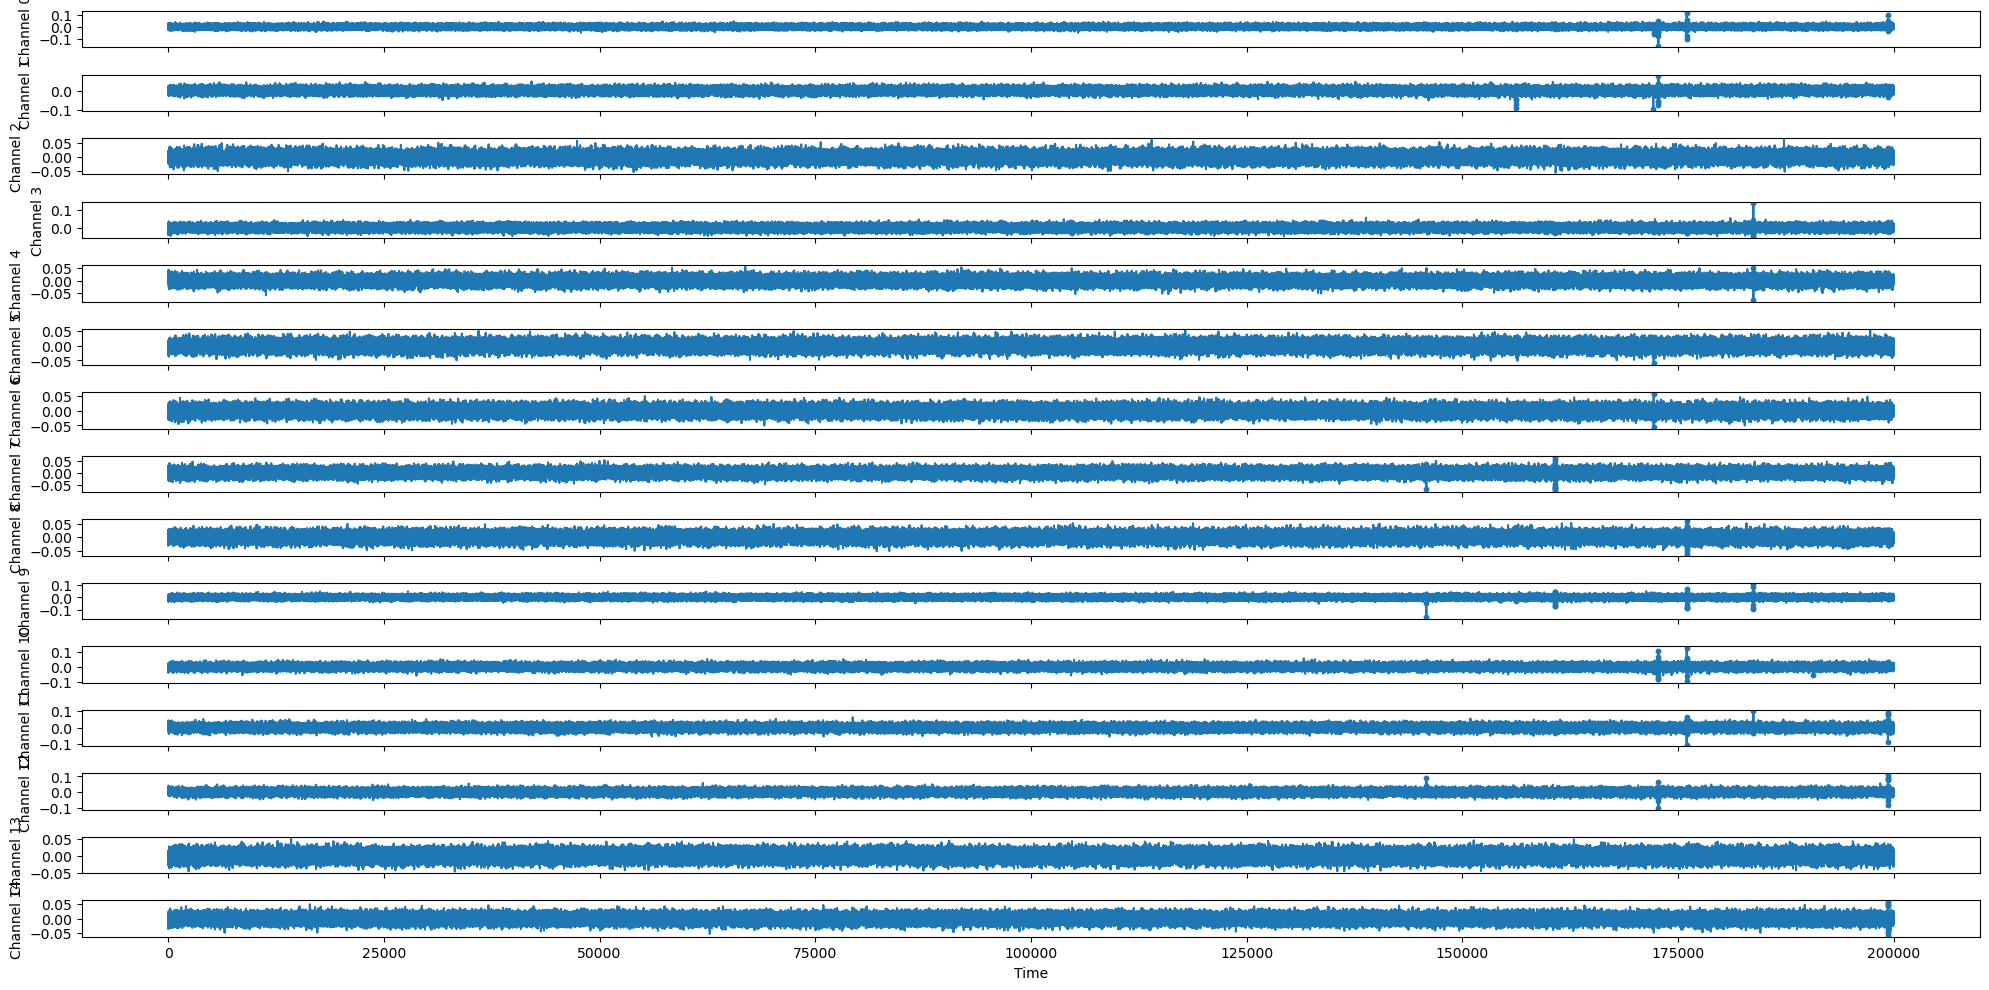

In [54]:
X,y,start = generate_dataset(type = 'ar')
plot_mts(X,y)

In [57]:
filenames = ['file_name']

for i in range(92,121):
    X,y,start = generate_dataset()
    filename = f"{i+1}_ARChannels_id_{i}_Sensor_tr_140000_1st_{min(start)}.csv"
    filenames.append(filename)
    df = pd.DataFrame(X, columns=[f"Channel_{j}" for j in range(X.shape[1])])
    df['Label'] = y
    df.to_csv(filename, index=False)

In [58]:
import csv
with open('my-data-Eva.csv', 'w', newline='') as file:
    writer = csv.writer(file)

    for name in filenames:
        writer.writerow([name])